In [122]:
import matplotlib as mpl

import jax

jax.config.update("jax_enable_x64", True)

In [23]:
ascent().shape

(512, 512)

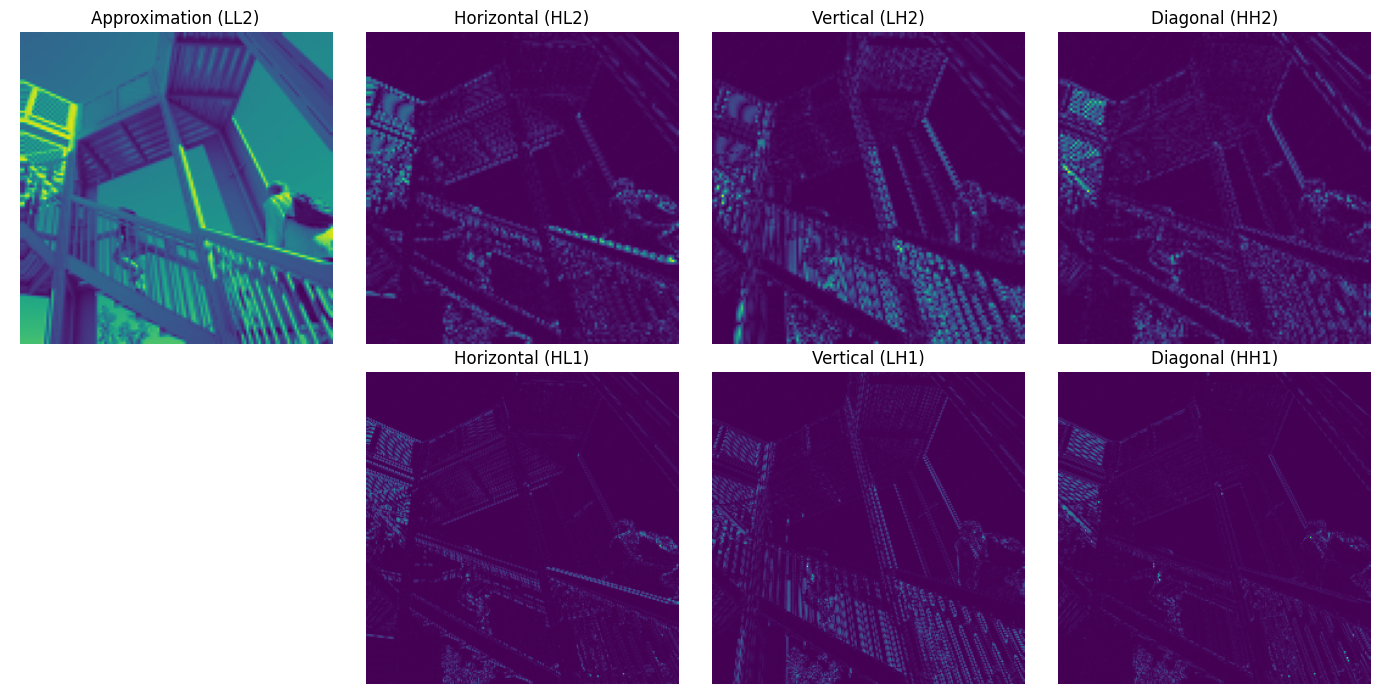

In [24]:
import jax.numpy as np
import jaxwt as jwt
import matplotlib.pyplot as plt
from scipy.datasets import face, ascent

# Load and preprocess the image
# image = np.transpose(ascent(), [1, 0, 2])  # [..., 0]  # Convert to grayscale
image = ascent().astype(np.float32) / 255.0

# Perform 2-level wavelet decomposition using the Haar wavelet
coeffs = jwt.wavedec2(image, wavelet="db2", level=2)

# Extract the decomposition coefficients
ll2, (hl2, lh2, hh2), (hl1, lh1, hh1) = coeffs

# Plotting corner plot visualization
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
titles = [
    "Approximation (LL2)",
    "Horizontal (HL2)",
    "Vertical (LH2)",
    "Diagonal (HH2)",
    "Horizontal (HL1)",
    "Vertical (LH1)",
    "Diagonal (HH1)",
]

coeff_plots = [ll2, hl2, lh2, hh2, hl1, lh1, hh1]
positions = [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3)]

# Plot each coefficient sub-band
for (i, j), coeff, title in zip(positions, coeff_plots, titles):
    ax = axes[i, j]
    ax.imshow(np.abs(coeff).squeeze(), cmap="viridis")
    ax.set_title(title)
    ax.axis("off")

axes[1, 0].axis("off")  # Hide unused subplot
plt.tight_layout()
plt.show()

In [100]:
# stack00 = np.hstack([ll2[0], hl2[0]])
stack00 = np.hstack([np.zeros_like(ll2)[0], hl2[0]])


stack01 = np.hstack([lh2[0], hh2[0]])

stack0 = np.vstack([stack00, stack01])

stack10 = np.hstack([stack0, np.pad(hl1[0], ((0, 3), (0, 3)))])

stack11 = np.hstack(
    [np.pad(lh1[0], ((0, 3), (0, 3))), np.pad(hh1[0], ((0, 3), (0, 3)))]
)

stack = np.vstack([stack10, stack11])

In [101]:
hl1_padded = np.pad(
    hl1,
    ((0, 0), (0, 3), (0, 3)),
    # mode="constant",
    # constant_values=0,
)
hl1_padded.shape

# def pad_to()

(1, 260, 260)

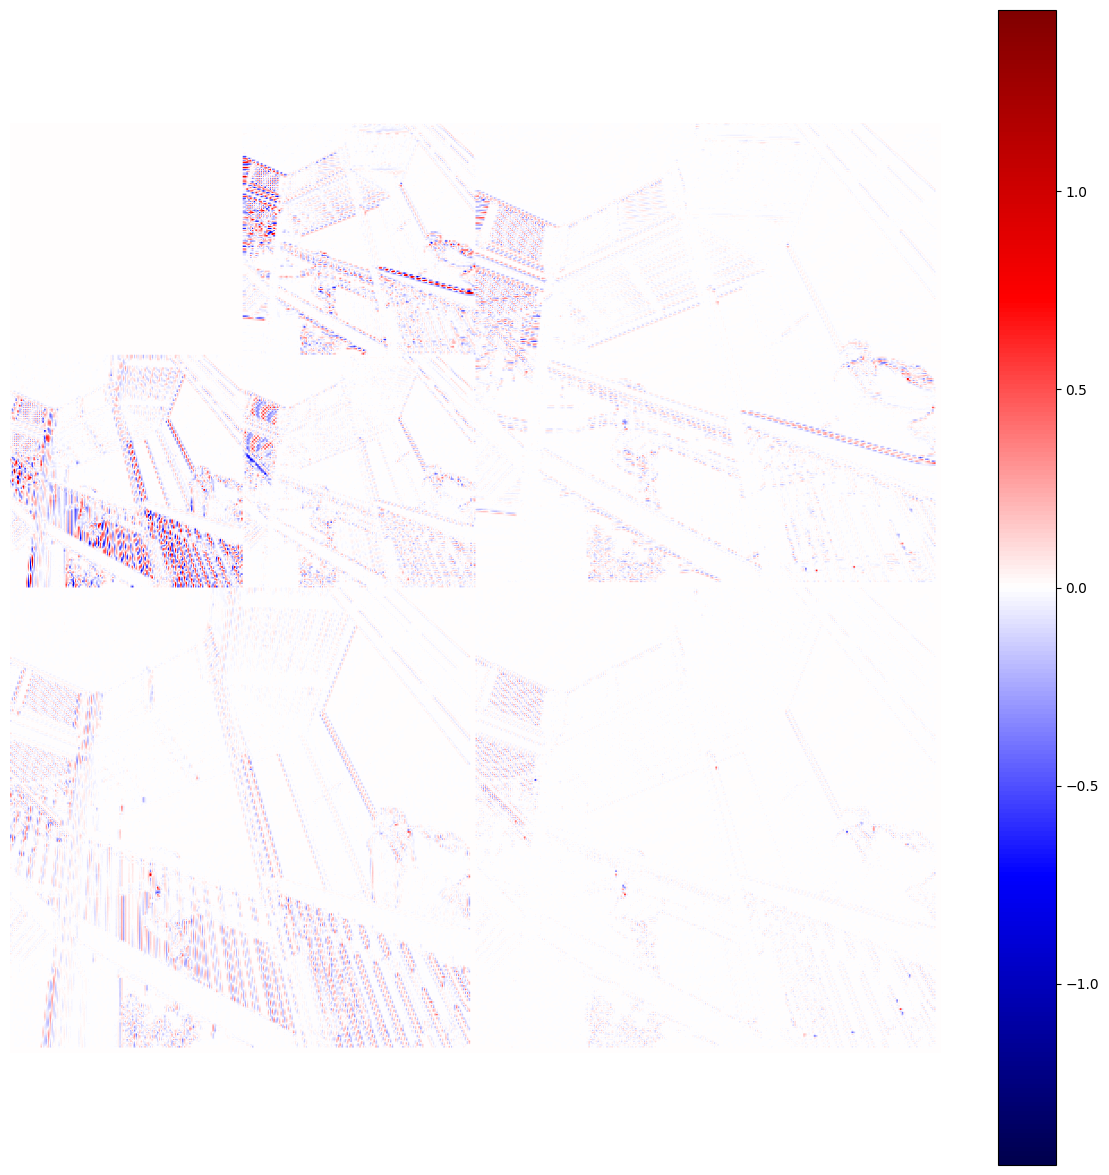

(520, 520)


In [103]:
plt.figure(figsize=(15, 15))
plt.imshow(stack.squeeze(), cmap="seismic", norm=mpl.colors.CenteredNorm(0))
plt.colorbar()
plt.axis("off")
plt.show()

print(stack.shape)

In [105]:
for wl in [ll2, hl2, lh2, hh2, hl1, lh1, hh1]:
    print(wl.shape, wl.sum())

(1, 130, 130) 23255.21
(1, 130, 130) 2.7396417
(1, 130, 130) -20.00638
(1, 130, 130) -16.536484
(1, 257, 257) 2.147571
(1, 257, 257) 12.346356
(1, 257, 257) -0.18555701


In [111]:
(image / 4).sum()

22482.67

In [ ]:
def normalise_wavelets(model, model_params, args, key):
    params = model_params.params

    if "wavelets" not in params.keys():
        return model_params, key

    # this is only to use methods! Does not update outside this function
    model = model.set("params", params)

    for k in params["wavelets"].keys():
        # reconstructing, normalising
        distribution = model._get_distribution_from_key(k)
        distribution = np.clip(distribution, 0.0)
        distribution = distribution / distribution.sum()

        # converting to wavelet coefficients
        norm_wavelets = model.wavelet_transform(distribution)
        norm_coeffs = model.flatten_wavelets(norm_wavelets)

        # re-assigning
        params["wavelets"][k] = norm_coeffs

    return model_params.set("params", params), key


In [124]:
image /= image.sum()

image.sum()

# Perform 2-level wavelet decomposition using the Haar wavelet
coeffs = jwt.wavedec2(image, wavelet="db2", level=2)

# Extract the decomposition coefficients
ll2, (hl2, lh2, hh2), (hl1, lh1, hh1) = coeffs

Array(0.25859043, dtype=float32)